# Coastal Water Level Variability Analysis (1986–2024)

## Project Overview

This notebook presents a Python-based analysis of long-term coastal tidal water level observations.

## Objectives

1. To preprocess and clean tidal water level data.
2. To analyse annual maximum water level variability.
3. To identify extreme high-water level events.
4. To investigate seasonal patterns of extreme water levels.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib

## 1. Data Import and Preprocessing

This section imports the required Python libraries, loads the tidal water level dataset, and performs initial data preprocessing including header correction, missing value removal, and date conversion.

In [1]:
import pandas as pd

In [2]:
import os

os.listdir(r"C:\Thisis\Data")

['107.2_data screening.xlsx',
 '107.2_data_screening_fixed.xlsx',
 'Al_lfinal_output_Strom surge.xlsx',
 'Doxt',
 'final_output_leave_one_out SW107.2.xlsx',
 'final_output_leave_one_out_SW107.2_1885-2016.xlsx',
 'final_output_leave_one_out_SW20.xlsx',
 'final_output_leave_one_out_SW241.xlsx',
 'final_output_leave_one_out_SW241_1885-2016.xlsx',
 'final_output_leave_one_out_SW243.xlsx',
 'final_output_leave_one_out_SW2431885-2016.xlsx',
 'final_output_leave_one_out_SW244.xlsx',
 'final_output_leave_one_out_SW244_1885-2016.xlsx',
 'GEV',
 'Gumble',
 'last_SW107.2.xls',
 'Monthly anomaly',
 'POT_GPD',
 'Results_and_Discussion_Initial_with_Annual_and_Climatological_Charts.docx',
 'Water_Level_Daily_High-Low_(Tidal)_SW107.2_2602279545.xlsx',
 'Water_Level_Daily_High-Low_(Tidal)_SW20_2602279545.xlsx',
 'Water_Level_Daily_High-Low_(Tidal)_SW241_2602279545.xlsx',
 'Water_Level_Daily_High-Low_(Tidal)_SW243_2602279545.xlsx',
 'Water_Level_Daily_High-Low_(Tidal)_SW244_2602279545.xlsx']

In [4]:
data = pd.read_excel(r"C:\Thisis\Data\Water_Level_Daily_High-Low_(Tidal)_SW20_2602279545.xlsx")

In [5]:
data.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12706 entries, 0 to 12705
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  12696 non-null  object
 1   Unnamed: 1  12695 non-null  str   
 2   Unnamed: 2  12695 non-null  object
 3   Unnamed: 3  12695 non-null  object
 4   Unnamed: 4  12695 non-null  object
dtypes: object(4), str(1)
memory usage: 496.5+ KB


In [7]:
data.shape

(12706, 5)

In [8]:
data.head(20)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN
9,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL)


In [9]:
data.tail(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
12696,12687,24/03/2026,0.8,-0.82,0
12697,12688,25/03/2026,0.65,-0.8,-0.04
12698,12689,26/03/2026,0.52,-0.77,-0.08
12699,12690,27/03/2026,0.45,-0.65,-0.07
12700,12691,28/03/2026,0.15,-0.68,-0.2
12701,12692,29/03/2026,0.55,-0.62,-0.09
12702,12693,30/03/2026,0.8,-0.63,-0.02
12703,12694,31/03/2026,0.9,-0.65,0.02
12704,NaN,NaN,NaN,NaN,NaN
12705,This document is system generated and does not...,NaN,NaN,NaN,NaN


In [15]:
header=10

In [16]:
data = pd.read_excel(
    r"C:\Thisis\Data\Water_Level_Daily_High-Low_(Tidal)_SW20_2602279545.xlsx",
    header=10
)

data.head()

,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL)
0,1,01/01/1986,0.169,-1.301,-0.561
1,2,02/01/1986,0.119,-1.211,-0.541
2,3,03/01/1986,0.079,-1.341,-0.631
3,4,04/01/1986,0.049,-1.361,-0.651
4,5,05/01/1986,-0.031,-1.381,-0.701


In [17]:
data.columns

Index(['SL', 'Date', 'Daily Max WL (mMSL)', 'Daily Min WL (mMSL)',
       'Daily Avg WL (mMSL)'],
      dtype='str')

In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12696 entries, 0 to 12695
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SL                   12695 non-null  object 
 1   Date                 12694 non-null  str    
 2   Daily Max WL (mMSL)  12694 non-null  float64
 3   Daily Min WL (mMSL)  12694 non-null  float64
 4   Daily Avg WL (mMSL)  12694 non-null  float64
dtypes: float64(3), object(1), str(1)
memory usage: 496.1+ KB


In [19]:
data.isnull().sum()

SL                     1
Date                   2
Daily Max WL (mMSL)    2
Daily Min WL (mMSL)    2
Daily Avg WL (mMSL)    2
dtype: int64

In [20]:
data.shape

(12696, 5)

In [21]:
data = data.dropna()

In [24]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [25]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12694 entries, 0 to 12693
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   SL                   12694 non-null  object        
 1   Date                 12694 non-null  datetime64[us]
 2   Daily Max WL (mMSL)  12694 non-null  float64       
 3   Daily Min WL (mMSL)  12694 non-null  float64       
 4   Daily Avg WL (mMSL)  12694 non-null  float64       
dtypes: datetime64[us](1), float64(3), object(1)
memory usage: 496.0+ KB


In [26]:
data.head()

,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL)
0,1,1986-01-01,0.169,-1.301,-0.561
1,2,1986-01-02,0.119,-1.211,-0.541
2,3,1986-01-03,0.079,-1.341,-0.631
3,4,1986-01-04,0.049,-1.361,-0.651
4,5,1986-01-05,-0.031,-1.381,-0.701


In [31]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt


In [5]:
import pandas as pd

In [7]:
data = pd.read_excel(
    r"C:\Thisis\Data\Water_Level_Daily_High-Low_(Tidal)_SW20_2602279545.xlsx",
    header=10)

In [8]:
data = data.dropna()

In [9]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [10]:
data.head()

,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL)
0,1,1986-01-01,0.169,-1.301,-0.561
1,2,1986-01-02,0.119,-1.211,-0.541
2,3,1986-01-03,0.079,-1.341,-0.631
3,4,1986-01-04,0.049,-1.361,-0.651
4,5,1986-01-05,-0.031,-1.381,-0.701


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_excel(
    r"C:\Thisis\Data\Water_Level_Daily_High-Low_(Tidal)_SW20_2602279545.xlsx",
    header=10
)

data = data.dropna()

data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [13]:
data.head()

,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL)
0,1,1986-01-01,0.169,-1.301,-0.561
1,2,1986-01-02,0.119,-1.211,-0.541
2,3,1986-01-03,0.079,-1.341,-0.631
3,4,1986-01-04,0.049,-1.361,-0.651
4,5,1986-01-05,-0.031,-1.381,-0.701


## 2. Statistical Analysis

This section evaluates the basic statistical characteristics of the water level dataset, including descriptive statistics, maximum and minimum values, and identification of extreme observations.

In [14]:
data['Daily Avg WL (mMSL)'].describe()

count    12694.000000
mean         0.140489
std          0.386922
min         -1.001000
25%         -0.161000
50%          0.149000
75%          0.449000
max          1.890000
Name: Daily Avg WL (mMSL), dtype: float64

In [15]:
data['Daily Max WL (mMSL)'].nlargest(10)

12020    2.950
3422     2.709
10923    2.689
10552    2.639
5504     2.599
5503     2.589
6242     2.589
11368    2.589
6240     2.539
10924    2.539
Name: Daily Max WL (mMSL), dtype: float64

In [16]:
extreme_events = data.nlargest(10, 'Daily Max WL (mMSL)')

extreme_events

,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL)
12020,12021,2024-05-27,2.950,1.000,1.890
3422,3423,1995-05-16,2.709,-0.391,1.159
10923,10924,2021-05-26,2.689,0.139,1.179
10552,10553,2020-05-20,2.639,0.139,1.209
5504,5505,2001-08-21,2.599,-0.251,0.809
5503,5504,2001-08-20,2.589,-0.211,1.069
6242,6243,2003-08-29,2.589,-0.131,1.549
11368,11369,2022-08-14,2.589,0.029,0.999
6240,6241,2003-08-27,2.539,-0.161,1.179
10924,10925,2021-05-27,2.539,-0.011,1.029


In [17]:
extreme_events[['Date','Daily Max WL (mMSL)']]

,Date,Daily Max WL (mMSL)
12020,2024-05-27,2.950
3422,1995-05-16,2.709
10923,2021-05-26,2.689
10552,2020-05-20,2.639
5504,2001-08-21,2.599
5503,2001-08-20,2.589
6242,2003-08-29,2.589
11368,2022-08-14,2.589
6240,2003-08-27,2.539
10924,2021-05-27,2.539


## 3. Annual Maximum Water Level Analysis

This section extracts annual maximum water levels from daily observations to evaluate long-term variability. A linear trend analysis is performed to examine the temporal behaviour of extreme water levels during the study period.

In [18]:
data['Year'] = data['Date'].dt.year

In [19]:
annual_max = data.groupby('Year')['Daily Max WL (mMSL)'].max()

annual_max

Year
1986    2.119
1987    1.899
1988    1.899
1989    1.989
1990    2.089
1991    2.009
1992    1.919
1993    2.059
1994    2.369
1995    2.709
1996    2.109
1997    1.689
1998    2.189
1999    2.069
2000    2.319
2001    2.599
2002    2.459
2003    2.589
2008    1.819
2009    1.629
2010    1.959
2011    1.499
2012    1.649
2013    1.699
2014    2.239
2015    2.189
2016    2.209
2017    2.339
2018    2.349
2019    2.139
2020    2.639
2021    2.689
2022    2.589
2023    2.240
2024    2.950
2025    2.350
2026    1.350
Name: Daily Max WL (mMSL), dtype: float64

In [20]:
annual_max = annual_max.reset_index()

annual_max.head()

,Year,Daily Max WL (mMSL)
0,1986,2.119
1,1987,1.899
2,1988,1.899
3,1989,1.989
4,1990,2.089


In [21]:
data['Year'] = data['Date'].dt.year

In [22]:
annual_max = data.groupby('Year')['Daily Max WL (mMSL)'].max()

annual_max

Year
1986    2.119
1987    1.899
1988    1.899
1989    1.989
1990    2.089
1991    2.009
1992    1.919
1993    2.059
1994    2.369
1995    2.709
1996    2.109
1997    1.689
1998    2.189
1999    2.069
2000    2.319
2001    2.599
2002    2.459
2003    2.589
2008    1.819
2009    1.629
2010    1.959
2011    1.499
2012    1.649
2013    1.699
2014    2.239
2015    2.189
2016    2.209
2017    2.339
2018    2.349
2019    2.139
2020    2.639
2021    2.689
2022    2.589
2023    2.240
2024    2.950
2025    2.350
2026    1.350
Name: Daily Max WL (mMSL), dtype: float64

In [23]:
annual_max = data.groupby('Year')['Daily Max WL (mMSL)'].max()

annual_max = annual_max.reset_index()

annual_max.head()

,Year,Daily Max WL (mMSL)
0,1986,2.119
1,1987,1.899
2,1988,1.899
3,1989,1.989
4,1990,2.089


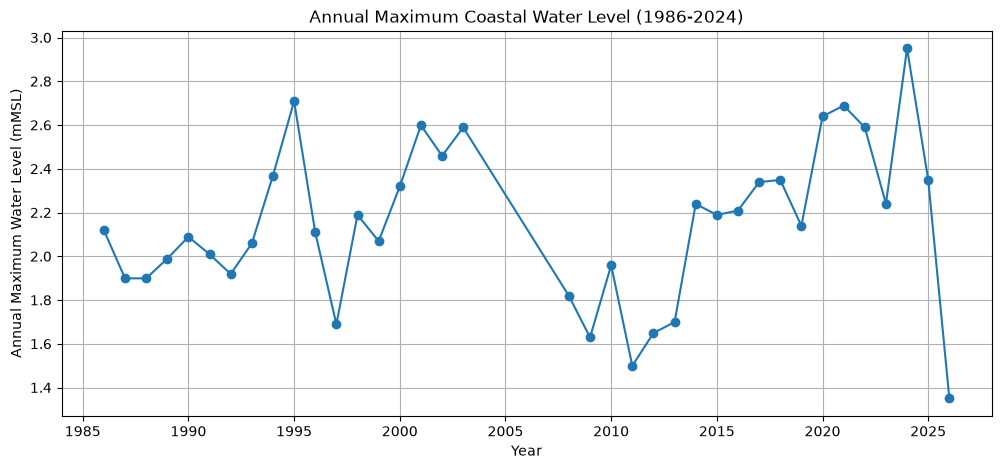

In [24]:
plt.figure(figsize=(12,5))

plt.plot(
    annual_max['Year'],
    annual_max['Daily Max WL (mMSL)'],
    marker='o'
)

plt.xlabel("Year")
plt.ylabel("Annual Maximum Water Level (mMSL)")
plt.title("Annual Maximum Coastal Water Level (1986-2024)")

plt.grid(True)

plt.show()

In [25]:
import numpy as np

x = annual_max['Year']
y = annual_max['Daily Max WL (mMSL)']

trend = np.polyfit(x, y, 1)

trend_line = np.polyval(trend, x)

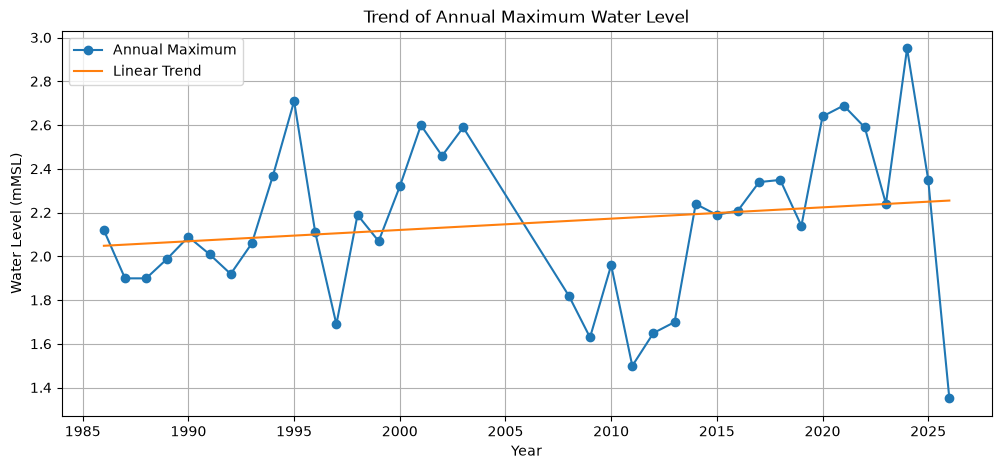

In [26]:
plt.figure(figsize=(12,5))

plt.plot(x, y, marker='o', label="Annual Maximum")

plt.plot(
    x,
    trend_line,
    label="Linear Trend"
)

plt.xlabel("Year")
plt.ylabel("Water Level (mMSL)")
plt.title("Trend of Annual Maximum Water Level")

plt.legend()
plt.grid(True)

plt.show()

In [27]:
slope = trend[0]

print("Annual change =", slope, "m/year")

Annual change = 0.005167331278222455 m/year


In [28]:
years = annual_max['Year'].max() - annual_max['Year'].min()

change = slope * years

print("Total change =", change, "m")

Total change = 0.20669325112889822 m


In [30]:
import numpy as np

ss_res = np.sum((y - trend_line)**2)

ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

print("R² =", r2)

R² = 0.032072438022075045


In [31]:
data['Month'] = data['Date'].dt.month

In [32]:
monthly_max = data.groupby('Month')['Daily Max WL (mMSL)'].max()

monthly_max

Month
1     1.669
2     1.689
3     1.909
4     1.989
5     2.950
6     2.269
7     2.339
8     2.599
9     2.369
10    2.539
11    2.139
12    1.839
Name: Daily Max WL (mMSL), dtype: float64

In [33]:
data['Month'] = data['Date'].dt.month

In [34]:
monthly_max = data.groupby('Month')['Daily Max WL (mMSL)'].max()

monthly_max

Month
1     1.669
2     1.689
3     1.909
4     1.989
5     2.950
6     2.269
7     2.339
8     2.599
9     2.369
10    2.539
11    2.139
12    1.839
Name: Daily Max WL (mMSL), dtype: float64

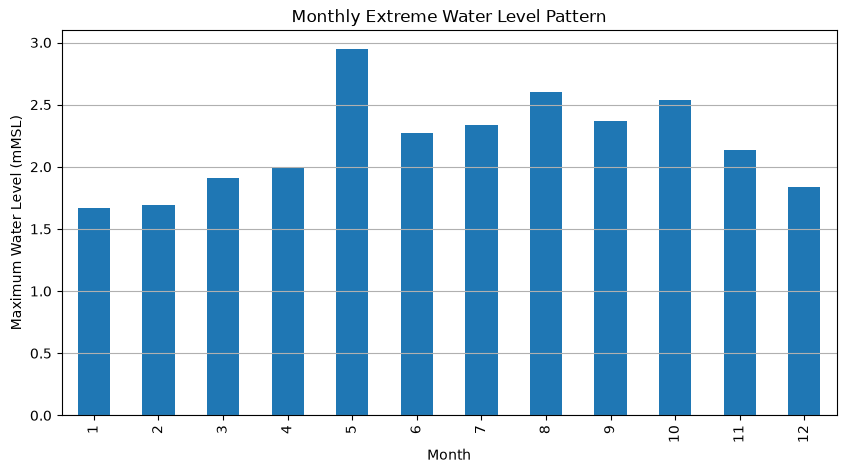

In [35]:
plt.figure(figsize=(10,5))

monthly_max.plot(kind='bar')

plt.xlabel("Month")
plt.ylabel("Maximum Water Level (mMSL)")
plt.title("Monthly Extreme Water Level Pattern")

plt.grid(axis='y')

plt.show()

In [38]:
len(extreme_days)

12

In [39]:
extreme_frequency = extreme_days.groupby('Year').size()

extreme_frequency

Year
1995    2
2001    2
2003    2
2020    1
2021    2
2022    2
2024    1
dtype: int64

## 4. Extreme Event Identification

This section identifies extreme high-water level events using a predefined threshold. Events exceeding the selected water level threshold are extracted and analysed to understand their temporal distribution and frequency.

In [40]:
threshold = 2.5

extreme_days = data[data['Daily Max WL (mMSL)'] > threshold]

extreme_days.head()

,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL),Year,Month
3421,3422,1995-05-15,2.509,-0.541,0.989,1995,5
3422,3423,1995-05-16,2.709,-0.391,1.159,1995,5
5503,5504,2001-08-20,2.589,-0.211,1.069,2001,8
5504,5505,2001-08-21,2.599,-0.251,0.809,2001,8
6240,6241,2003-08-27,2.539,-0.161,1.179,2003,8


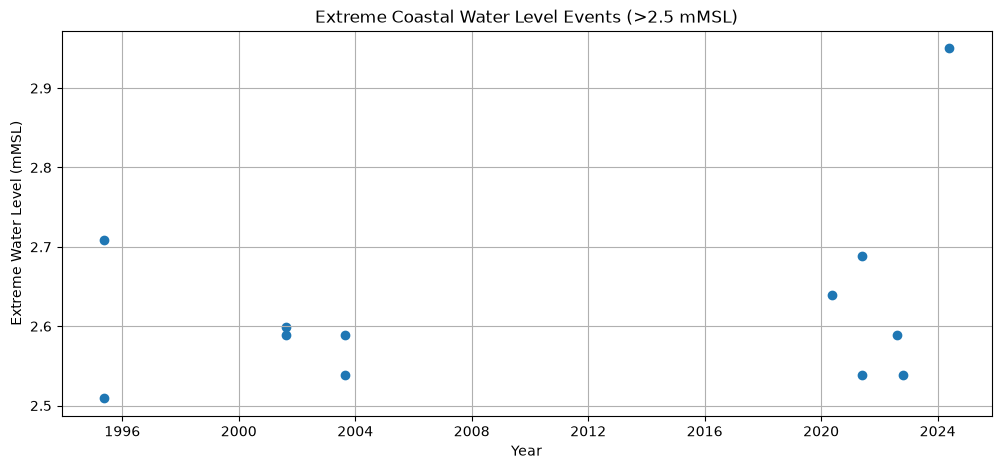

In [42]:
plt.figure(figsize=(12,5))

plt.scatter(
    extreme_days['Date'],
    extreme_days['Daily Max WL (mMSL)']
)

plt.xlabel("Year")
plt.ylabel("Extreme Water Level (mMSL)")
plt.title("Extreme Coastal Water Level Events (>2.5 mMSL)")

plt.grid(True)

plt.show()

In [44]:
id="7x7z8p"
extreme_summary = extreme_days[
    ['Date',
     'Year',
     'Month',
     'Daily Max WL (mMSL)']
]

extreme_summary

,Date,Year,Month,Daily Max WL (mMSL)
3421,1995-05-15,1995,5,2.509
3422,1995-05-16,1995,5,2.709
5503,2001-08-20,2001,8,2.589
5504,2001-08-21,2001,8,2.599
6240,2003-08-27,2003,8,2.539
6242,2003-08-29,2003,8,2.589
10552,2020-05-20,2020,5,2.639
10923,2021-05-26,2021,5,2.689
10924,2021-05-27,2021,5,2.539
11368,2022-08-14,2022,8,2.589


In [45]:
id="m4x7gq"
extreme_summary.to_csv(
    "Extreme_Water_Level_Events.csv",
    index=False
)

In [46]:
plt.savefig("annual_maximum_trend.png", dpi=300, bbox_inches='tight')



<Figure size 640x480 with 0 Axes>

In [2]:
figure_path = r"C:\Thisis\Data\Coastal_Water_Level_Analysis_Python\Figures"

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
data = pd.read_excel(
    r"C:\Thisis\Data\Coastal_Water_Level_Analysis_Python\Data\Water_Level_Daily_High-Low_(Tidal)_SW20_2602279545.xlsx",
    header=10
)

data = data.dropna()

data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

data.head()

,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL)
0,1,1986-01-01,0.169,-1.301,-0.561
1,2,1986-01-02,0.119,-1.211,-0.541
2,3,1986-01-03,0.079,-1.341,-0.631
3,4,1986-01-04,0.049,-1.361,-0.651
4,5,1986-01-05,-0.031,-1.381,-0.701


## 5. Seasonal Analysis

This section investigates the seasonal behaviour of extreme water levels by analysing monthly variations. Monthly maximum water levels are extracted to identify periods with higher extreme water level conditions.

In [7]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

In [8]:
annual_max = data.groupby('Year')['Daily Max WL (mMSL)'].max()

annual_max = annual_max.reset_index()

annual_max.head()

,Year,Daily Max WL (mMSL)
0,1986,2.119
1,1987,1.899
2,1988,1.899
3,1989,1.989
4,1990,2.089


In [9]:
figure_path = r"C:\Thisis\Data\Coastal_Water_Level_Analysis_Python\Figures"

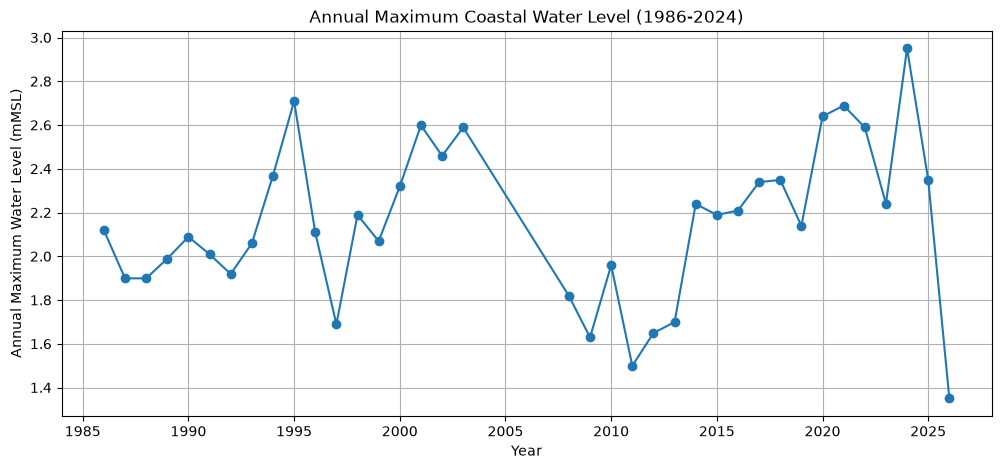

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    annual_max['Year'],
    annual_max['Daily Max WL (mMSL)'],
    marker='o'
)

plt.xlabel("Year")
plt.ylabel("Annual Maximum Water Level (mMSL)")
plt.title("Annual Maximum Coastal Water Level (1986-2024)")

plt.grid(True)

plt.savefig(
    figure_path + r"\annual_maximum_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
monthly_max = data.groupby('Month')['Daily Max WL (mMSL)'].max()

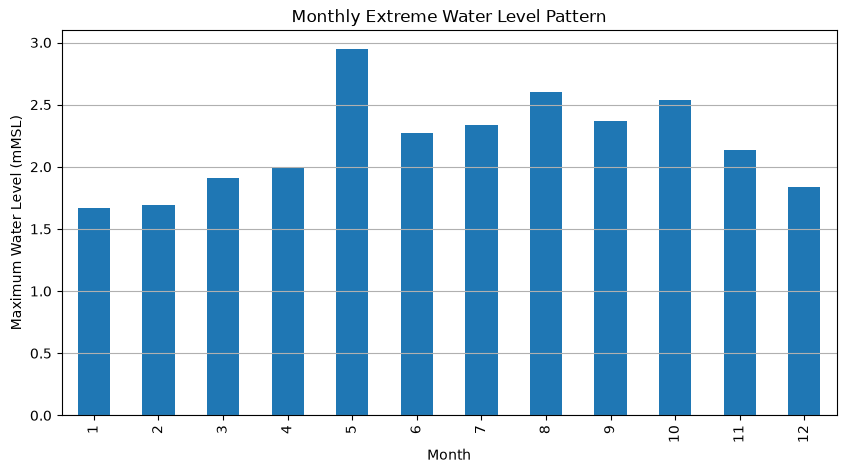

In [13]:
plt.figure(figsize=(10,5))

monthly_max.plot(kind='bar')

plt.xlabel("Month")
plt.ylabel("Maximum Water Level (mMSL)")
plt.title("Monthly Extreme Water Level Pattern")

plt.grid(axis='y')

plt.savefig(
    figure_path + r"\monthly_extreme_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
threshold = 2.5

extreme_days = data[data['Daily Max WL (mMSL)'] > threshold]

extreme_days.head()

,SL,Date,Daily Max WL (mMSL),Daily Min WL (mMSL),Daily Avg WL (mMSL),Year,Month
3421,3422,1995-05-15,2.509,-0.541,0.989,1995,5
3422,3423,1995-05-16,2.709,-0.391,1.159,1995,5
5503,5504,2001-08-20,2.589,-0.211,1.069,2001,8
5504,5505,2001-08-21,2.599,-0.251,0.809,2001,8
6240,6241,2003-08-27,2.539,-0.161,1.179,2003,8


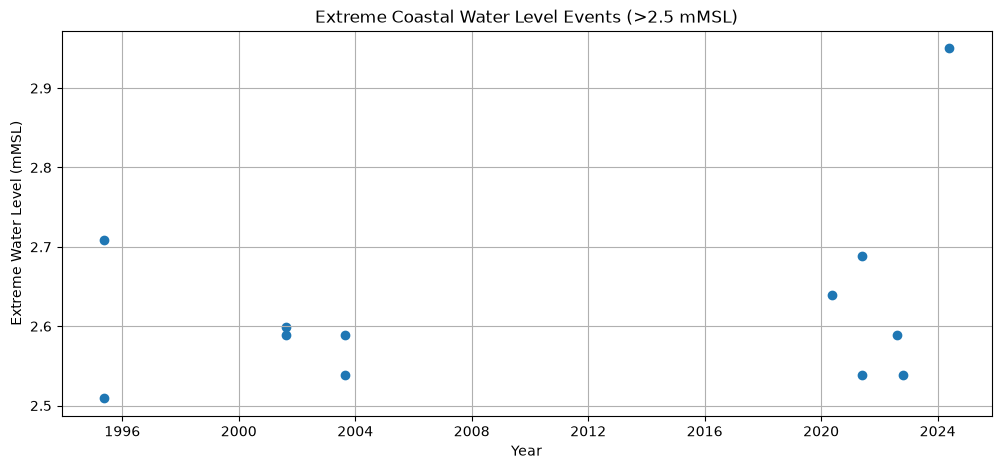

In [15]:
plt.figure(figsize=(12,5))

plt.scatter(
    extreme_days['Date'],
    extreme_days['Daily Max WL (mMSL)']
)

plt.xlabel("Year")
plt.ylabel("Extreme Water Level (mMSL)")
plt.title("Extreme Coastal Water Level Events (>2.5 mMSL)")

plt.grid(True)

plt.savefig(
    figure_path + r"\extreme_events_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Results Summary

The analysis produced the following main findings:

- A total of 12,694 daily water level observations were retained after data preprocessing.
- The highest recorded daily maximum water level was 2.950 mMSL on 27 May 2024.
- Twelve extreme high-water events were identified using a threshold of >2.5 mMSL.
- The annual maximum water level series showed an increasing linear tendency of approximately 0.00517 m/year.
- The linear trend had a low coefficient of determination (R² ≈ 0.033), indicating substantial year-to-year variability.
- Seasonal analysis showed the highest observed extreme water level in May, with relatively high values also occurring in August and October.

These results demonstrate the use of Python for reproducible processing, statistical analysis, and visualization of long-term coastal water level observations.